# Importing Libraries & Dataset

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

In [ ]:
train = pd.read_csv(r"Ahmed236664\credit_score.csv")
train

In [38]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

# Data Cleaning & Preprocessing 

### Handling duplicates and unneeesary columns

In [39]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [40]:
#Dropping unnecessary columns, that won't affect the prediction
drop_columns = ['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Type_of_Loan']
train = train.drop(columns=drop_columns)

In [41]:
#Checking for duplicate rows
print(train.duplicated().sum())

0


### Spliting data into train & test

In [42]:
train, test = train_test_split(train, test_size=0.2, random_state=21)

### Handling data types

In [43]:
train.dtypes

Age                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                 object
dtype: object

In [44]:
#Selecting numeric columns stored as object
Numeric_columns = train.select_dtypes(include='object').columns.tolist()
#Removing categorical columns from the list
Numeric_columns.remove('Occupation')
Numeric_columns.remove('Credit_Mix')
Numeric_columns.remove('Credit_History_Age')
Numeric_columns.remove('Payment_of_Min_Amount')
Numeric_columns.remove('Payment_Behaviour')
Numeric_columns.remove('Credit_Score')
Numeric_columns

['Age',
 'Annual_Income',
 'Num_of_Loan',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Outstanding_Debt',
 'Amount_invested_monthly',
 'Monthly_Balance']

In [45]:
train[Numeric_columns]

,Age,Annual_Income,Num_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Outstanding_Debt,Amount_invested_monthly,Monthly_Balance
12309,20,14455.15,0,17,10.56,1028.5,106.41712654015149,274.84245679318184
91699,48,21834.84,-100,5,8.73,597.77,64.6398831048489,321.5422846987166
90457,30_,112302.04,3,12,2.39,734.94,175.70219268320758,716.5870676847155
78861,24,29038.58,7_,20,15.24,1583.12,82.82380880688267,314.52265330813424
29219,53,40457.96,0,6,5.86,340.15,317.8857368625989,281.86392980406777
...,...,...,...,...,...,...,...,...
81968,35,10263.79,1,NaN,2.73,730.77,23.722000049517828,308.4949720734904
8964,22,15803.96,4,19,13.25,931.32,81.60084825512847,264.16157387164907
71480,21,26223.67,3,8,8.06,462.91,182.40160019973598,271.5658528932337
70863,41,67672.4,5,24,0.5,1826.19,442.5540329040722,181.9820095051817


#### Normalizing data

In [46]:
# Remove underscores and convert to numeric
for col in Numeric_columns:
    train[col] = train[col].replace('_', np.nan)
    train[col] = pd.to_numeric(train[col], errors='coerce')

    test[col] = test[col].replace('_', np.nan)
    test[col] = pd.to_numeric(test[col], errors='coerce')

In [47]:
# Change Credit_History_Age to numeric by converting
# "22 Years and 1 Months" -> 265 (months)

def convert_credit_history_age(age_str):
    if pd.isna(age_str):
        return np.nan
    years = int(age_str.split('Years')[0].strip())
    months = int(age_str.split('and')[1].split('Months')[0].strip())
    return years * 12 + months

convert_credit_history_age("22 Years and 1 Months")

265

In [48]:
train['Credit_History_Age'] = train['Credit_History_Age'].apply(convert_credit_history_age)
test['Credit_History_Age'] = test['Credit_History_Age'].apply(convert_credit_history_age)

### Handling nulls, missing values, and incorrect data

In [49]:
# Only 89.767% of age values are between 16 and 100
# other values are likely errors or people under the legal age to have a credit card
# I will replace values outside this range with NaN, and then fill them with the mean of ages
correct_age_range = (train['Age'] >= 16) & (train['Age'] <= 100)
(train['Age'][correct_age_range].count() / len(train['Age'])) * 100


np.float64(89.7675)

In [50]:
#Replace incorrect values with null
incorrect_age_range_train = (train['Age'] < 16) | (train['Age'] > 100)
train.loc[incorrect_age_range_train, 'Age'] = np.nan

incorrect_age_range_test = (test['Age'] < 16) | (test['Age'] > 100)
test.loc[incorrect_age_range_test, 'Age'] = np.nan

# Fill missing Age values with the mean age
mean_age = round(train['Age'].mean())
train['Age'] = train['Age'].fillna(mean_age)
test['Age'] = test['Age'].fillna(mean_age)

In [51]:
# Percentage of missing values per column
(train.isnull().sum() / len(train) * 100).sort_values(ascending=False)

Monthly_Inhand_Salary       15.04250
Num_of_Delayed_Payment       9.78625
Credit_History_Age           8.95125
Amount_invested_monthly      8.75000
Annual_Income                6.90375
Num_of_Loan                  4.77750
Changed_Credit_Limit         2.09625
Num_Credit_Inquiries         1.97000
Monthly_Balance              1.21500
Outstanding_Debt             0.99375
Num_Credit_Card              0.00000
Num_Bank_Accounts            0.00000
Age                          0.00000
Occupation                   0.00000
Credit_Mix                   0.00000
Delay_from_due_date          0.00000
Interest_Rate                0.00000
Credit_Utilization_Ratio     0.00000
Total_EMI_per_month          0.00000
Payment_of_Min_Amount        0.00000
Payment_Behaviour            0.00000
Credit_Score                 0.00000
dtype: float64

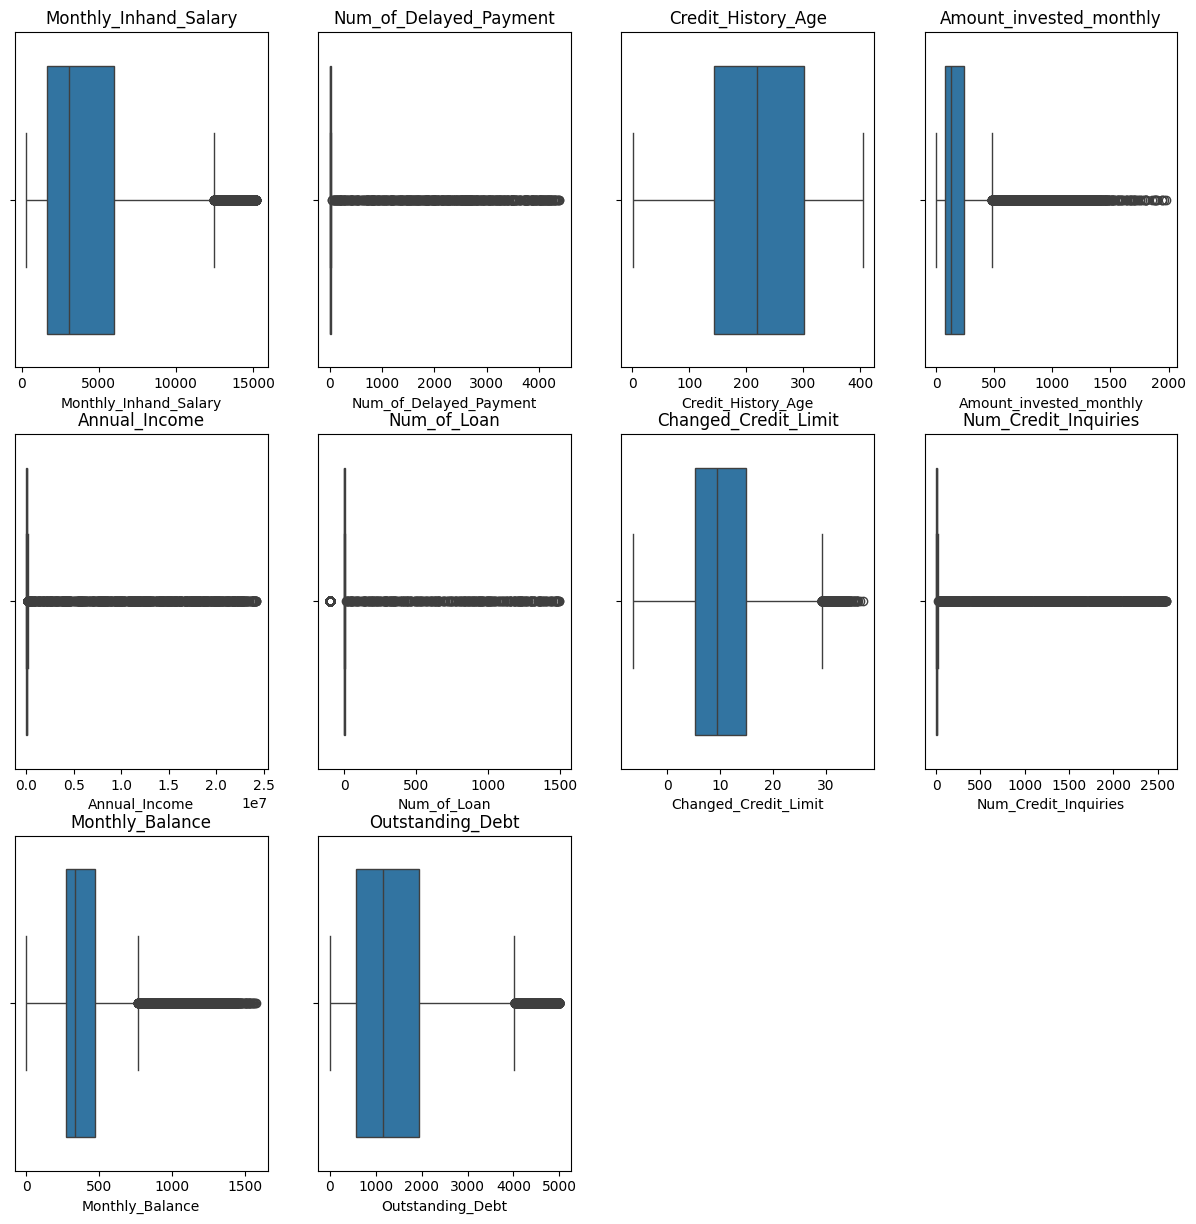


Monthly_Inhand_Salary:
Mean:   4200.347087499589
Median: 3097.6966666666667
Relative Difference: 35.59581648836681%

Num_of_Delayed_Payment:
Mean:   30.827770156988265
Median: 14.0
Relative Difference: 120.19835826420189%

Credit_History_Age:
Mean:   220.99564793585853
Median: 219.0
Relative Difference: 0.9112547652322047%

Amount_invested_monthly:
Mean:   195.94147229258954
Median: 129.33608610281527
Relative Difference: 51.497913843493414%

Annual_Income:
Mean:   179210.62679202977
Median: 37486.02
Relative Difference: 378.0732304790687%

Num_of_Loan:
Mean:   2.802869594896164
Median: 3.0
Relative Difference: 6.571013503461194%

Changed_Credit_Limit:
Mean:   10.407908787967774
Median: 9.41
Relative Difference: 10.604769266395042%

Num_Credit_Inquiries:
Mean:   27.2489926553096
Median: 6.0
Relative Difference: 354.1498775884933%

Monthly_Balance:
Mean:   402.58155096064166
Median: 336.68688319074215
Relative Difference: 19.571498344522205%

Outstanding_Debt:
Mean:   1427.321371125560

In [52]:
# Plotting the distribution of columns with missing values
# to decide how to fill the missing values (either with median or mean)
# for data skewed to the right use median
# for normally distributed data use mean 

cols = ['Monthly_Inhand_Salary', 'Num_of_Delayed_Payment', 'Credit_History_Age',
        'Amount_invested_monthly', 'Annual_Income', 'Num_of_Loan', 'Changed_Credit_Limit',
        'Num_Credit_Inquiries', 'Monthly_Balance', 'Outstanding_Debt']

plt.figure(figsize=(15, 20))
for i, col in enumerate(cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(x=train[col])
    plt.title(col)
plt.show()

for col in cols:
    print(f"\n{col}:")
    print(f"Mean:   {train[col].mean()}")
    print(f"Median: {train[col].median()}")
    print(f"Relative Difference: {(abs(train[col].mean() - train[col].median()) / train[col].median()) * 100}%")


In [53]:
# For columns with high relative difference between mean and median
# I will fill missing values with median as data is skewed
# And for columns with low relative difference, 
# I will fill missing values with mean as data is normally distributed

cols_Median = ['Num_Credit_Inquiries', 'Num_of_Delayed_Payment','Monthly_Inhand_Salary', 'Amount_invested_monthly', 'Annual_Income', 'Changed_Credit_Limit', 'Monthly_Balance', 'Outstanding_Debt']
cols_Mean = ['Credit_History_Age', 'Num_of_Loan']
for col in cols_Median:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())

for col in cols_Mean:
    train[col] = train[col].fillna(round(train[col].mean()))
    test[col] = test[col].fillna(round(train[col].mean()))

In [54]:
# Percentage of missing values per column
(train.isnull().sum() / len(train) * 100).sort_values(ascending=False)

Age                         0.0
Occupation                  0.0
Annual_Income               0.0
Monthly_Inhand_Salary       0.0
Num_Bank_Accounts           0.0
Num_Credit_Card             0.0
Interest_Rate               0.0
Num_of_Loan                 0.0
Delay_from_due_date         0.0
Num_of_Delayed_Payment      0.0
Changed_Credit_Limit        0.0
Num_Credit_Inquiries        0.0
Credit_Mix                  0.0
Outstanding_Debt            0.0
Credit_Utilization_Ratio    0.0
Credit_History_Age          0.0
Payment_of_Min_Amount       0.0
Total_EMI_per_month         0.0
Amount_invested_monthly     0.0
Payment_Behaviour           0.0
Monthly_Balance             0.0
Credit_Score                0.0
dtype: float64

### Handling outliers

In [55]:
# Checking for outliers in all numeric columns using IQR method
num_cols =["Age","Annual_Income","Monthly_Inhand_Salary","Num_Bank_Accounts","Num_Credit_Card","Interest_Rate","Num_of_Loan","Delay_from_due_date","Num_of_Delayed_Payment","Changed_Credit_Limit","Num_Credit_Inquiries","Outstanding_Debt","Credit_Utilization_Ratio","Credit_History_Age","Total_EMI_per_month","Amount_invested_monthly","Monthly_Balance"]
outlier_percent = {}

for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    total_rows = len(train)
    outliers = train[(train[col] < lower) | (train[col] > upper)]
    outlier_percent[col] = round(len(outliers) / total_rows * 100)
    print(f"{col}: {outlier_percent[col]}% outliers")

Age: 0% outliers
Annual_Income: 3% outliers
Monthly_Inhand_Salary: 4% outliers
Num_Bank_Accounts: 1% outliers
Num_Credit_Card: 2% outliers
Interest_Rate: 2% outliers
Num_of_Loan: 4% outliers
Delay_from_due_date: 4% outliers
Num_of_Delayed_Payment: 1% outliers
Changed_Credit_Limit: 1% outliers
Num_Credit_Inquiries: 2% outliers
Outstanding_Debt: 5% outliers
Credit_Utilization_Ratio: 0% outliers
Credit_History_Age: 0% outliers
Total_EMI_per_month: 7% outliers
Amount_invested_monthly: 9% outliers
Monthly_Balance: 8% outliers


In [56]:
# Since the percentage of outliers is lower than 10%, I will cap the outliers to the lower and upper bounds
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    train[col] = train[col].clip(lower, upper)
    test[col] = test[col].clip(lower,upper)

### Encoding categorical columns

In [57]:
# Encoding for categorical columns
train.dtypes

Age                         float64
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card             float64
Interest_Rate                 int64
Num_of_Loan                 float64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
Credit_Score                 object
dtype: object

In [58]:
# Checking unique values and number of unique values in categorical columns
# This will enable me to choose between label encoding and one-hot encoding
categorical_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']
for col in categorical_cols:
    print(f"\n{col}:")
    print(train[col].unique())
    print(train[col].nunique())


Occupation:
['Engineer' '_______' 'Mechanic' 'Entrepreneur' 'Architect' 'Journalist'
 'Manager' 'Writer' 'Developer' 'Musician' 'Media_Manager' 'Doctor'
 'Accountant' 'Lawyer' 'Scientist' 'Teacher']
16

Credit_Mix:
['Standard' 'Good' 'Bad' '_']
4

Payment_of_Min_Amount:
['Yes' 'No' 'NM']
3

Payment_Behaviour:
['Low_spent_Small_value_payments' 'High_spent_Small_value_payments'
 'High_spent_Large_value_payments' '!@9#%8'
 'Low_spent_Medium_value_payments' 'High_spent_Medium_value_payments'
 'Low_spent_Large_value_payments']
7

Credit_Score:
['Standard' 'Good' 'Poor']
3


#### Normalizing data

In [59]:
# Replace missing values with nulls, then fill them with mode
train['Occupation'] = train['Occupation'].replace('_______', np.nan)
train['Credit_Mix'] = train['Credit_Mix'].replace('_', np.nan)
train['Payment_of_Min_Amount'] = train['Payment_of_Min_Amount'].replace('NM', np.nan)
train['Payment_Behaviour'] = train['Payment_Behaviour'].replace('!@9#%8', np.nan)

test['Occupation'] = test['Occupation'].replace('_______', np.nan)
test['Credit_Mix'] = test['Credit_Mix'].replace('_', np.nan)
test['Payment_of_Min_Amount'] = test['Payment_of_Min_Amount'].replace('NM', np.nan)
test['Payment_Behaviour'] = test['Payment_Behaviour'].replace('!@9#%8', np.nan)

for col in ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']:
    mode_value = train[col].mode()[0]
    train[col] = train[col].fillna(mode_value)
    test[col] = test[col].fillna(mode_value)

In [60]:
# For columns with low number of unique values, I will use label encode
# Credit_Score, Payment_of_Min_Amount, Credit_Mix

credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
train['Credit_Mix'] = train['Credit_Mix'].map(credit_mix_map)
test['Credit_Mix'] = test['Credit_Mix'].map(credit_mix_map)

pay_min_map = {'No': 0, 'Yes': 1}
train['Payment_of_Min_Amount'] = train['Payment_of_Min_Amount'].map(pay_min_map)
test['Payment_of_Min_Amount'] = test['Payment_of_Min_Amount'].map(pay_min_map)

credit_score_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
train['Credit_Score'] = train['Credit_Score'].map(credit_score_map)
test['Credit_Score'] = test['Credit_Score'].map(credit_score_map)

In [61]:
# For columns with high number of unique values, I will use one-hot encoding
train = pd.get_dummies(train, columns=['Occupation', 'Payment_Behaviour'], drop_first=True)
test = pd.get_dummies(test, columns=['Occupation', 'Payment_Behaviour'], drop_first=True)

# Feature Selection

### Feature Engineering

In [62]:
# Keeping a copy of the original data before feature selection
train_original = train
test_original = test

In [63]:
train.columns

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Score',
       'Occupation_Architect', 'Occupation_Developer', 'Occupation_Doctor',
       'Occupation_Engineer', 'Occupation_Entrepreneur',
       'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager',
       'Occupation_Mechanic', 'Occupation_Media_Manager',
       'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher',
       'Occupation_Writer',
       'Payment_Behaviour_High_spent_Medium_value_payments',
       'Payment_Behaviour_High_spent_Small_value_payments',
       'Payment_Behaviour_Low_spent_Large_value_

In [64]:
# Adding new features based on existing features

# Debt to income ratio
train['NEW_Debt_to_Income'] = train['Outstanding_Debt'] / train['Monthly_Inhand_Salary'].replace(0,1)
test['NEW_Debt_to_Income'] = test['Outstanding_Debt'] / test['Monthly_Inhand_Salary'].replace(0,1)

# Credit utilization ratio (debt vs credit limit)
train['NEW_Credit_Usage'] = train['Outstanding_Debt'] / train['Changed_Credit_Limit'].replace(0,1)
test['NEW_Credit_Usage'] = test['Outstanding_Debt'] / test['Changed_Credit_Limit'].replace(0,1)

# EMI vs Salary
train['NEW_EMI_to_Income'] = train['Total_EMI_per_month'] / train['Monthly_Inhand_Salary'].replace(0,1)
test['NEW_EMI_to_Income'] = test['Total_EMI_per_month'] / test['Monthly_Inhand_Salary'].replace(0,1)

# Investment to income ratio
train['NEW_Investment_to_Income'] = train['Amount_invested_monthly'] / train['Monthly_Inhand_Salary'].replace(0,1)
test['NEW_Investment_to_Income'] = test['Amount_invested_monthly'] / test['Monthly_Inhand_Salary'].replace(0,1)

# Average debt per account
train['NEW_Debt_per_Account'] = train['Outstanding_Debt'] / train['Num_Bank_Accounts'].replace(0,1)
test['NEW_Debt_per_Account'] = test['Outstanding_Debt'] / test['Num_Bank_Accounts'].replace(0,1)

# Credit per card
train['NEW_Credit_per_Card'] = train['Changed_Credit_Limit'] / train['Num_Credit_Card'].replace(0,1)
test['NEW_Credit_per_Card'] = test['Changed_Credit_Limit'] / test['Num_Credit_Card'].replace(0,1)


### Selection using: Correlation Matrix

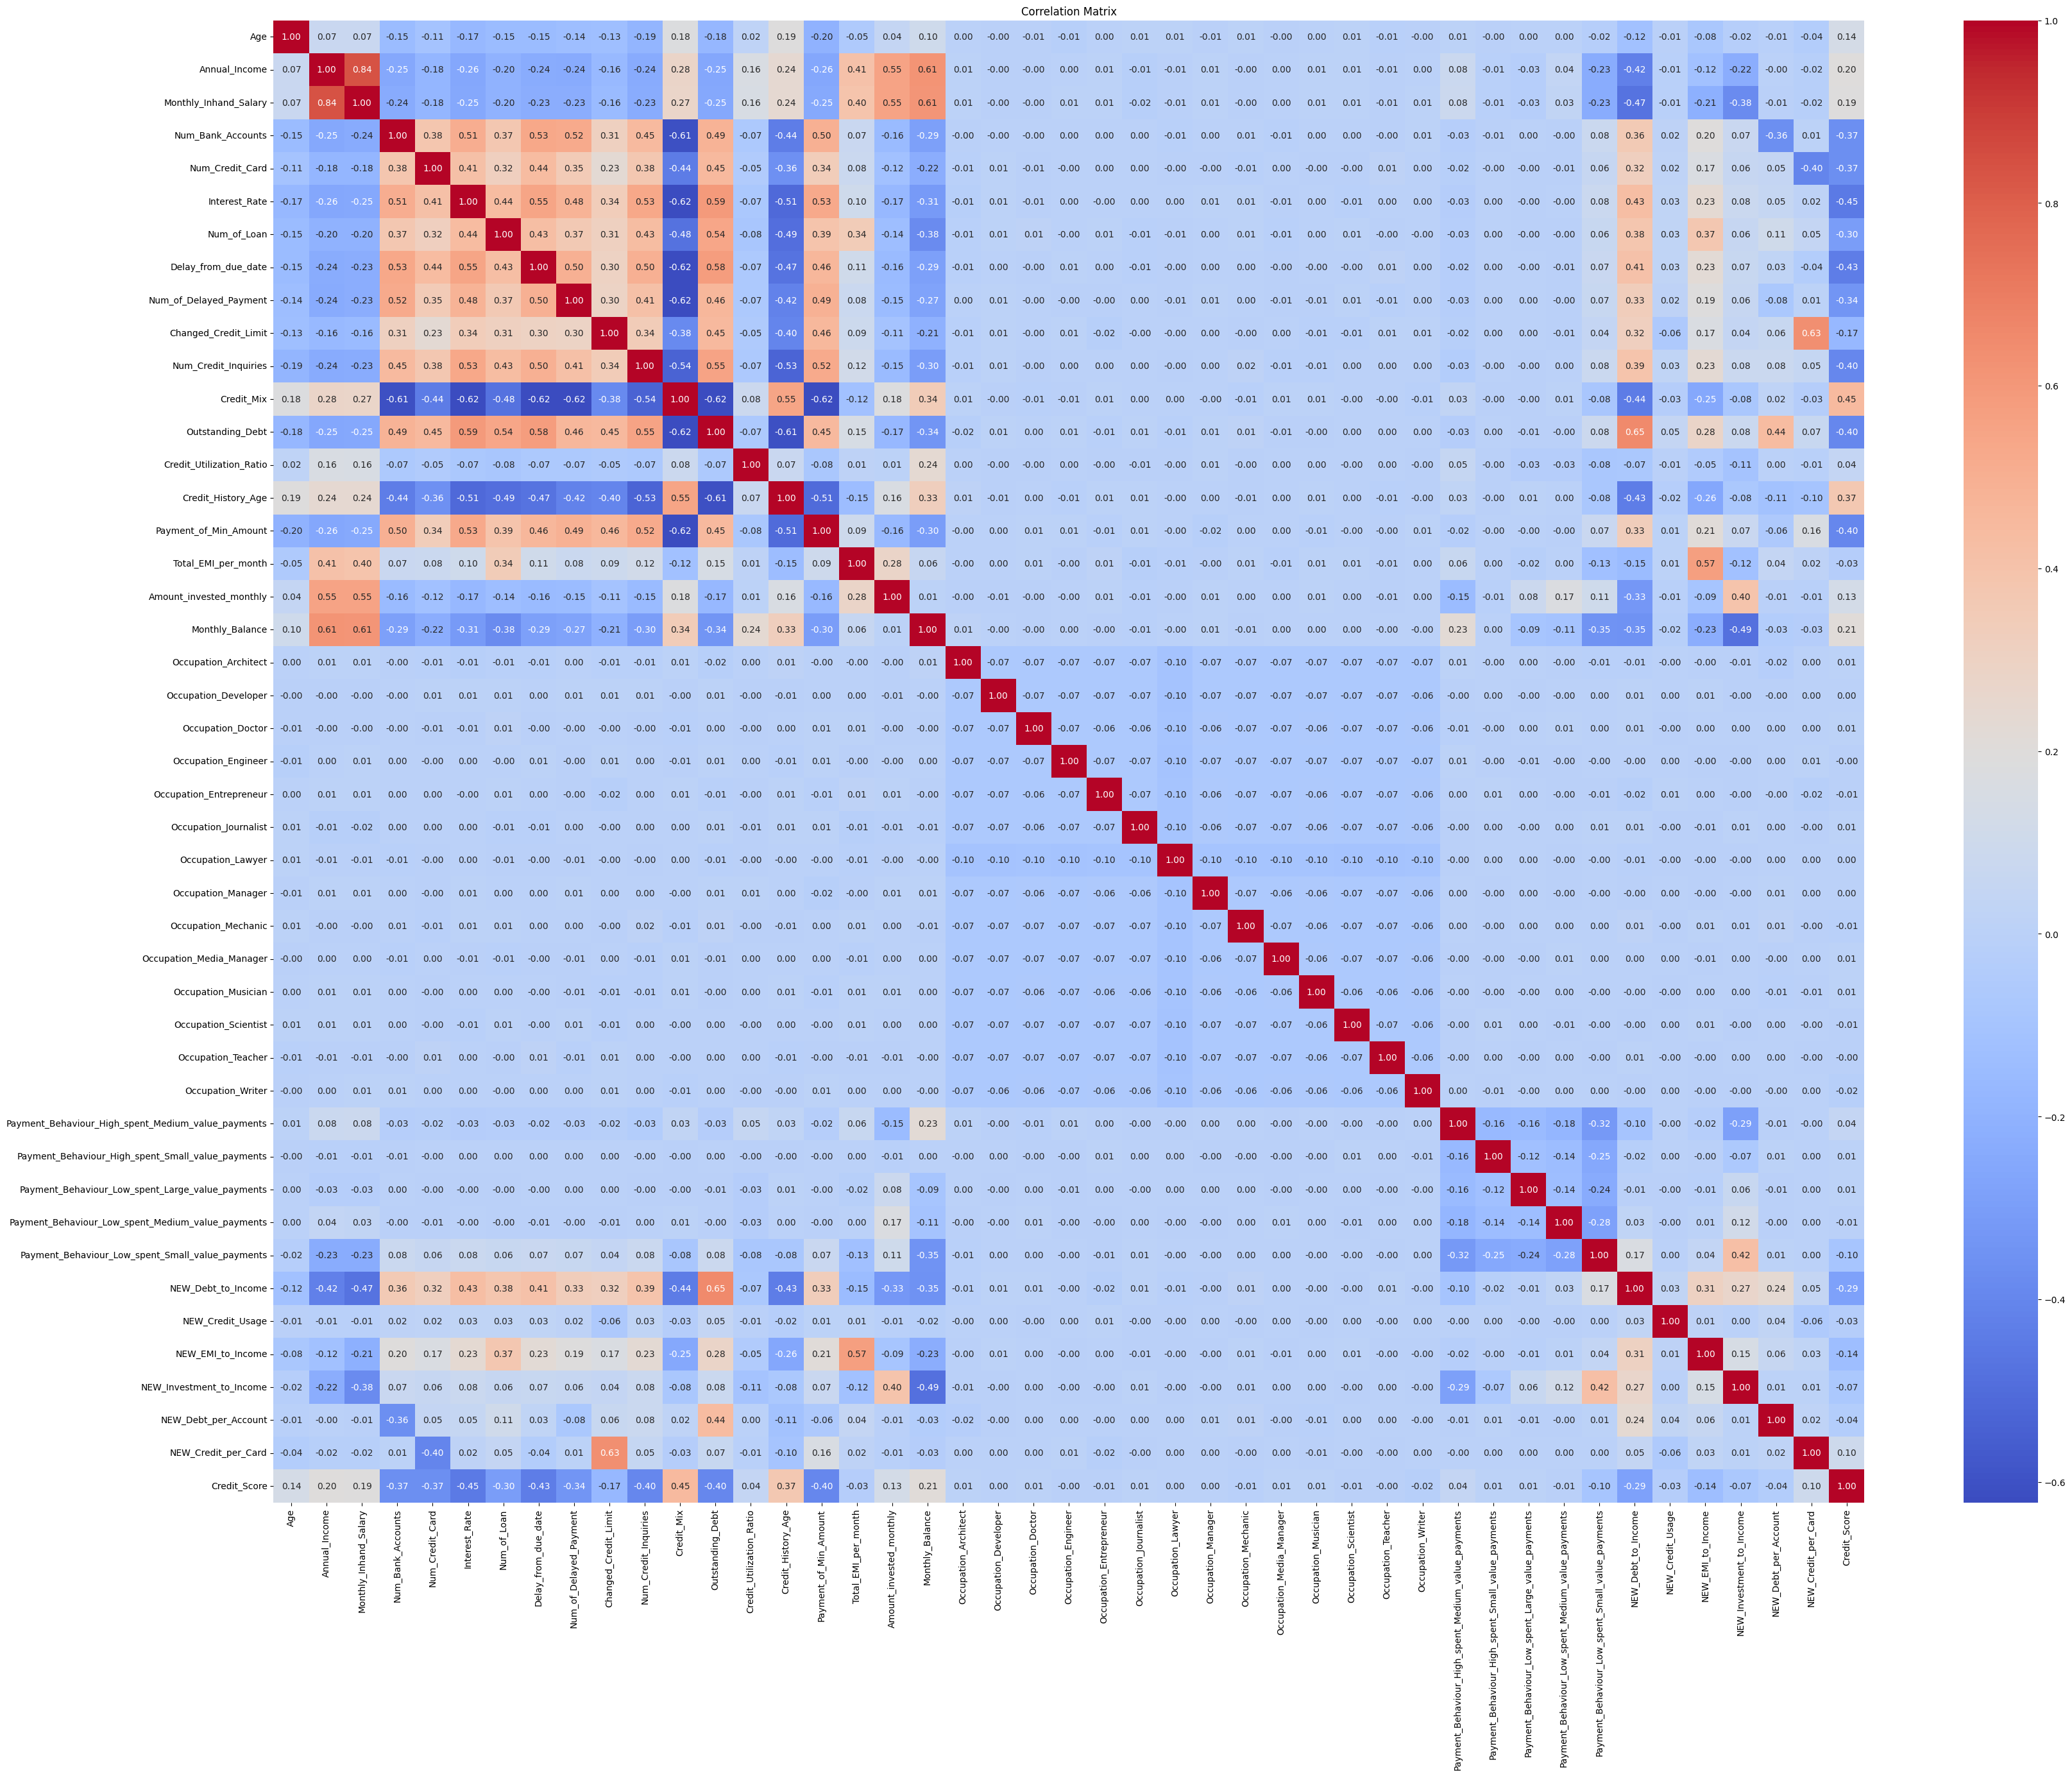

In [65]:
# Correlation matrix to see relationships between features

numeric_cols = [c for c in train if (pd.api.types.is_numeric_dtype(train[c])) & (c != 'Credit_Score')]
df_corr = train[numeric_cols + ['Credit_Score']]
corr_matrix = df_corr.corr()

plt.figure(figsize=(40, max(30, len(corr_matrix)*0.4)))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title(f"Correlation Matrix")
plt.show()

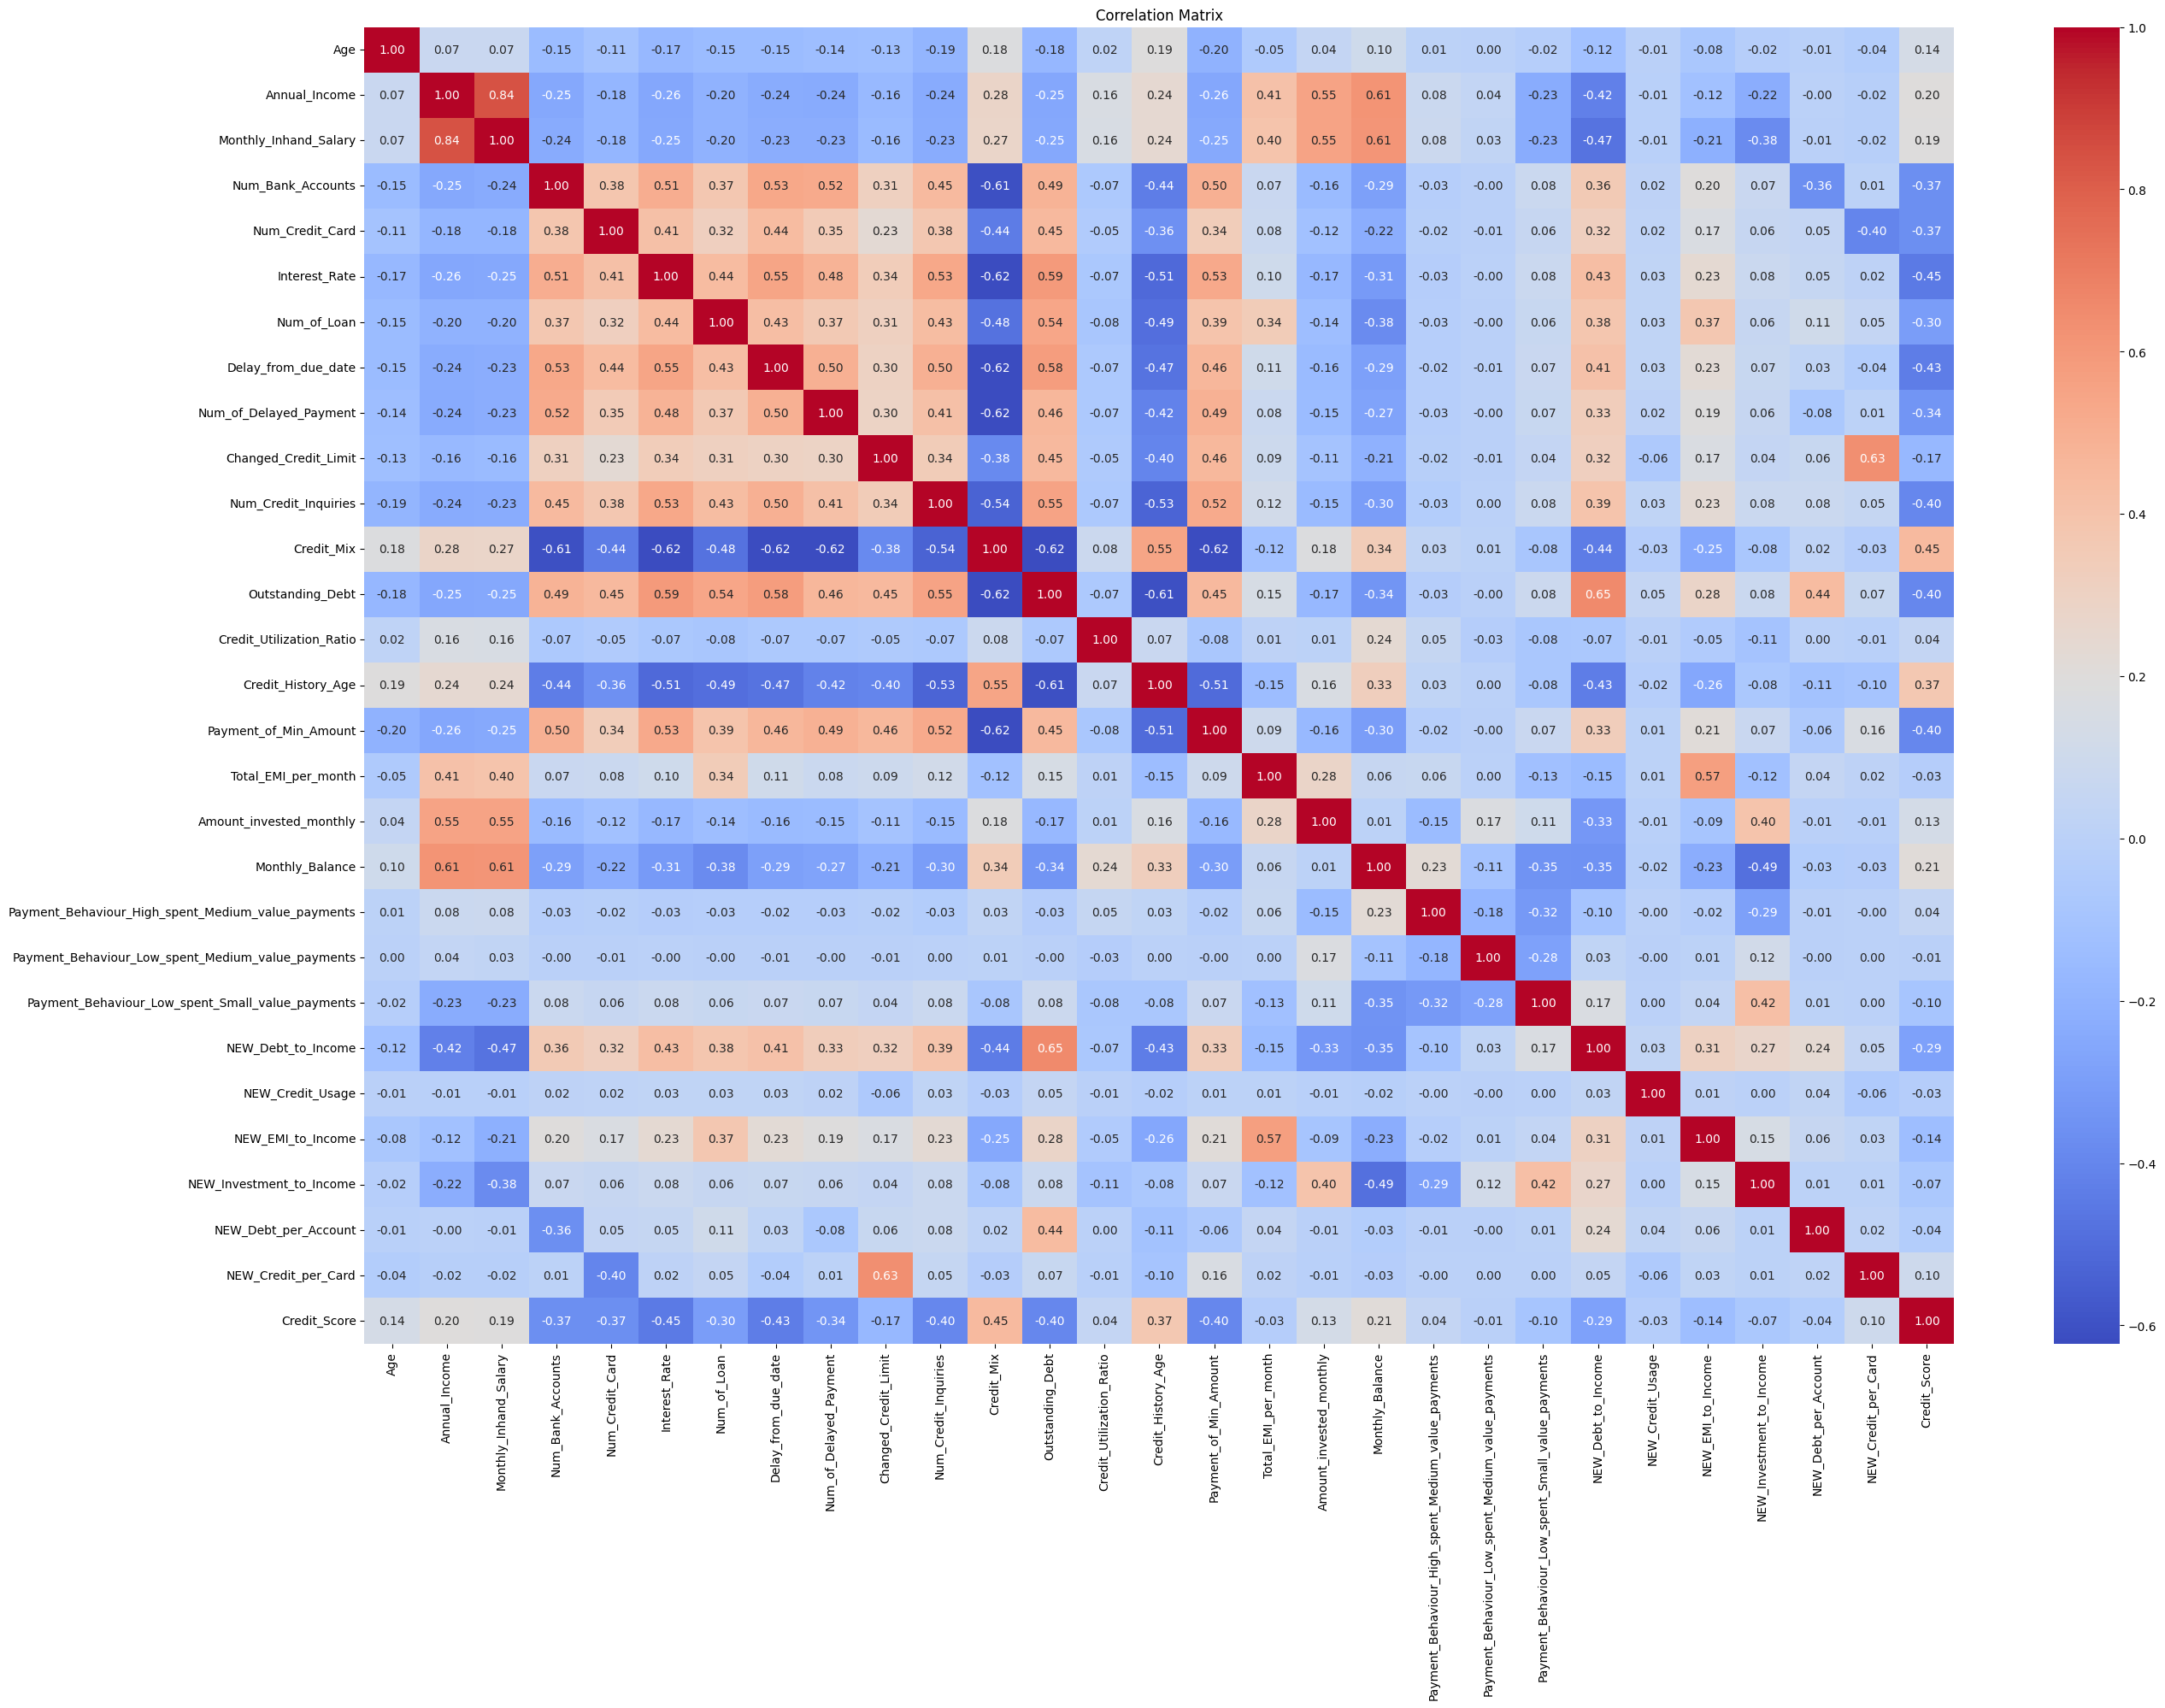

In [66]:
# After reviewing the features, I will remove all the folling:
# 1) Occupation one-hot encoded columns
# 2) Payment Behaviour High spent Small & Payment Behaviour Low spent Large
# As these features don't have any correlation with the credit score (<0.01)
# And also don't have any correlation with other features that may affect the credit score (<0.07)

unnesserary_cols = ["Occupation_Architect","Occupation_Developer","Occupation_Doctor",
                    "Occupation_Engineer","Occupation_Entrepreneur","Occupation_Journalist",
                    "Occupation_Lawyer","Occupation_Manager","Occupation_Mechanic","Occupation_Media_Manager",
                    "Occupation_Musician","Occupation_Scientist","Occupation_Teacher","Occupation_Writer",
                    "Payment_Behaviour_High_spent_Small_value_payments","Payment_Behaviour_Low_spent_Large_value_payments"]

train = train.drop(columns=unnesserary_cols)
test = test.drop(columns=unnesserary_cols)

# Final correlation matrix after removing the unnecessary columns
# All the featues here either directly affect credit score or have correlation with
# other feateures that affect credit score (indirect relationship)
numeric_cols = [c for c in train if (pd.api.types.is_numeric_dtype(train[c])) & (c != 'Credit_Score')]
df_corr = train[numeric_cols + ['Credit_Score']]
corr_matrix = df_corr.corr()

plt.figure(figsize=(30, max(20, len(corr_matrix)*0.4)))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title(f"Correlation Matrix")
plt.show()

### Selection using: Variance

In [67]:
X = train.iloc[:,0:-1]
y = train["Credit_Score"]
train.var().astype(int).sort_values(ascending=False)

Annual_Income                                         1362862325
Monthly_Inhand_Salary                                    7611375
NEW_Credit_Usage                                         3695531
Outstanding_Debt                                         1163994
NEW_Debt_per_Account                                       60669
Monthly_Balance                                            29850
Amount_invested_monthly                                    14941
Total_EMI_per_month                                        10919
Credit_History_Age                                          9070
Delay_from_due_date                                          208
Age                                                           97
Interest_Rate                                                 85
Changed_Credit_Limit                                          44
Num_of_Delayed_Payment                                        37
Credit_Utilization_Ratio                                      26
Num_Credit_Inquiries     

In [68]:
# Selecting the top features proposed by varriance techniques
# Where the variance is higher than 250 
selected_features = ["Annual_Income", "Monthly_Inhand_Salary", "NEW_Credit_Usage",
                   "Outstanding_Debt", "NEW_Debt_per_Account", "Monthly_Balance",
                   "Amount_invested_monthly", "Total_EMI_per_month", "Credit_History_Age"]
columns_to_keep = selected_features + ['Credit_Score']

train_variance = train.loc[:, columns_to_keep]
test_variance = test.loc[:, columns_to_keep]

# We will use this later in the training section

### Selection using: Step Forward Feature Selection (SFS) 

In [69]:
X_train_SFS = train.drop('Credit_Score', axis=1)
Y_train_SFS = train['Credit_Score']
X_test_SFS = test.drop('Credit_Score', axis=1)
Y_test_SFS = test['Credit_Score']

In [70]:
knn = KNeighborsClassifier(n_neighbors=4)

sfs = SFS(estimator=knn, k_features=(1, X_train_SFS.shape[1]),
          forward=True, floating=False, verbose=1,
          scoring='accuracy', cv=4, n_jobs=-1)

sfs = sfs.fit(X_train_SFS, Y_train_SFS)
print("Selected Feature Names:", sfs.k_feature_names_)
knn.fit(X_train_SFS.iloc[:, list(sfs.k_feature_idx_)], Y_train_SFS)

test_accuracy = knn.score(X_test_SFS.iloc[:, list(sfs.k_feature_idx_)], Y_test_SFS)
print("Test Accuracy:", test_accuracy)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 out of  28 | elapsed:   16.6s remaining:    1.2s
[Parallel(n_jobs=-1)]: Done  28 out of  28 | elapsed:   20.7s finished
Features: 1/28[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 out of  27 | elapsed:    2.6s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:    2.9s finished
Features: 2/28[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 out of  26 | elapsed:    2.7s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  26 out of  26 | elapsed:    3.0s finished
Features: 3/28[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  20 out of  25 | elapsed:    2.6s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:    3.0s finished
Features: 4/28[Parallel(n_jobs=-1)]: Using

Selected Feature Names: ('Interest_Rate', 'Outstanding_Debt', 'NEW_EMI_to_Income')
Test Accuracy: 0.7811


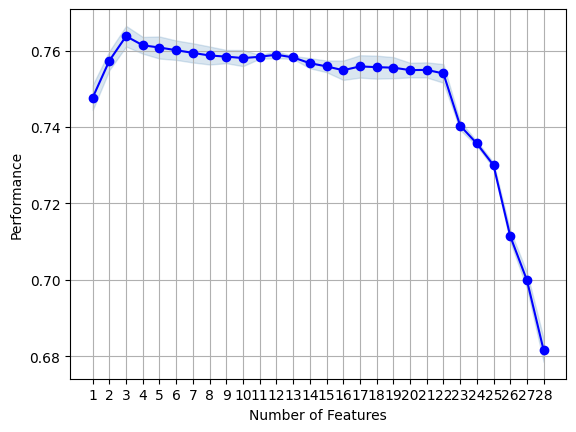

In [80]:
plot_sfs(sfs.get_metric_dict(), kind='std_dev')
plt.grid()

In [81]:
# Selecting the features proposed by the step forward selection model
selected_features = ['Outstanding_Debt', 'Interest_Rate', 'NEW_EMI_to_Income']
columns_to_keep = selected_features + ['Credit_Score']

train_SFS = train.loc[:, columns_to_keep]
test_SFS = test.loc[:, columns_to_keep]

# Training

The goal here is to predict 'Credit_Score', which is a categorical feature.  
This makes it a multi-class classification problem.
### Models to Explore
#### 1) Logistic Regression
- Serves as the baseline model for comparison.  
- Works well when the relationships between features and the credit score are linear.  

#### 2) Decision Tree Classifier
- Handles nonlinear relationships.  
- Works well with mixed data types (numerical + categorical).  

#### 3) K-Nearest Neighbors (KNN)
- A non-parametric model that doesn’t assume a specific data distribution.  
- Effective when similar instances tend to have similar credit scores.  
- Useful for detecting local patterns and neighborhood-based behavior.

### Datasets for Training

Each model will be trained on four datasets:

1. "train_original" – Original data without any feature selection - "Regular_Data"
2. "train" – Original data after Correlation Matrix - "Regular_Corr" 
3. "train_variance" – Same as "train" but with features selected using variance threshold - "Regular_Variance" 
4. "train_SFS" – Same as "train" but with features selected using Step Forward Selection (SFS) - "Regular_SFS

### Data Splitting

In [82]:
# Splitting data into X & Y train and test 
X_train_original = train_original.drop('Credit_Score', axis=1)
Y_train_original = train_original['Credit_Score']
X_test_original = test_original.drop('Credit_Score', axis=1)
Y_test_original = test_original['Credit_Score']

X_train = train.drop('Credit_Score', axis=1)
Y_train = train['Credit_Score']
X_test = test.drop('Credit_Score', axis=1)
Y_test = test['Credit_Score']

X_train_variance= train_variance.drop('Credit_Score', axis=1)
Y_train_variance = train_variance['Credit_Score']
X_test_variance= train_variance.drop('Credit_Score', axis=1)
Y_test_variance= train_variance['Credit_Score']

X_train_SFS = train_SFS.drop('Credit_Score', axis=1)
Y_train_SFS = train_SFS['Credit_Score']
X_test_SFS = test_SFS.drop('Credit_Score', axis=1)
Y_test_SFS = test_SFS['Credit_Score']

In [83]:
print(X_train_original.shape)
print(train.shape)
print(train_variance.shape)
print(train_SFS.shape)

(80000, 44)
(80000, 29)
(80000, 10)
(80000, 4)


In [84]:
datasets = [
    (X_train_original, X_test_original, Y_train_original, Y_test_original ,"Regular_Data"),
    (X_train, X_test, Y_train, Y_test, "Regular_Corr"),
    (X_train_variance, X_test_variance, Y_train_variance, Y_test_variance, "Regular_variance"),
    (X_train_SFS, X_test_SFS, Y_train_SFS, Y_test_SFS, "Regular_SFS")
]

#### Visualization

In [85]:
# This plot function will be used to draw the
# learning curve of the following trainings
def plot_learning_curve(model, X_train, y_train, title):    
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
    plt.plot(train_sizes, test_mean, label='Validation Score', marker='o')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [99]:
# This plot function will be used to draw the
# confusion matrices of each model
def plot_confusion_matrices(confusion_matrices, figsize=(12, 10), cmap='Blues'):
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    for idx, (name, cm) in enumerate(confusion_matrices):
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=axes[idx])
        axes[idx].set_title(f'Confusion Matrix - {name}')
        axes[idx].set_ylabel('True Label')
        axes[idx].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()

### Training: Logistic Regression

In [87]:
logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=21))
])

logreg_params = {
    'logreg__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2', 'elasticnet'],
    'logreg__solver': ['saga'],
    'logreg__l1_ratio': [0.25, 0.5, 0.75]
}

results = []
models_logreg = []
confusion_matrices_logreg = []

for X_train, X_test, Y_train, Y_test, name in datasets:
    print(f"\n==================== {name} ====================\n")

    grid = GridSearchCV(logreg_pipe, logreg_params, cv=5, n_jobs=-1, verbose=1)
    grid.fit(X_train, Y_train)

    Y_pred = grid.predict(X_test)
    acc = accuracy_score(Y_test, Y_pred)

    print("Best Params:", grid.best_params_)
    print(classification_report(Y_test, Y_pred))
    
    cm = confusion_matrix(Y_test, Y_pred)
    confusion_matrices_logreg.append((name, cm))
    results.append([name, acc])
    models_logreg.append((grid.best_estimator_, X_train, Y_train, name))

results_df = pd.DataFrame(results, columns=["Dataset", "Accuracy"])
print("\n=========== FINAL ACCURACY SUMMARY ===========\n")
print(results_df.to_string(index=False))


==================== Regular_Data ====================

Fitting 5 folds for each of 63 candidates, totalling 315 fits
Best Params: {'logreg__C': 0.01, 'logreg__l1_ratio': 0.25, 'logreg__penalty': 'l1', 'logreg__solver': 'saga'}
              precision    recall  f1-score   support

           0       0.61      0.69      0.65      5832
           1       0.78      0.56      0.65     10605
           2       0.47      0.77      0.59      3563

    accuracy                           0.64     20000
   macro avg       0.62      0.67      0.63     20000
weighted avg       0.68      0.64      0.64     20000


==================== Regular_Corr ====================

Fitting 5 folds for each of 63 candidates, totalling 315 fits
Best Params: {'logreg__C': 0.1, 'logreg__l1_ratio': 0.25, 'logreg__penalty': 'l1', 'logreg__solver': 'saga'}
              precision    recall  f1-score   support

           0       0.61      0.69      0.65      5832
           1       0.78      0.56      0.65     10605

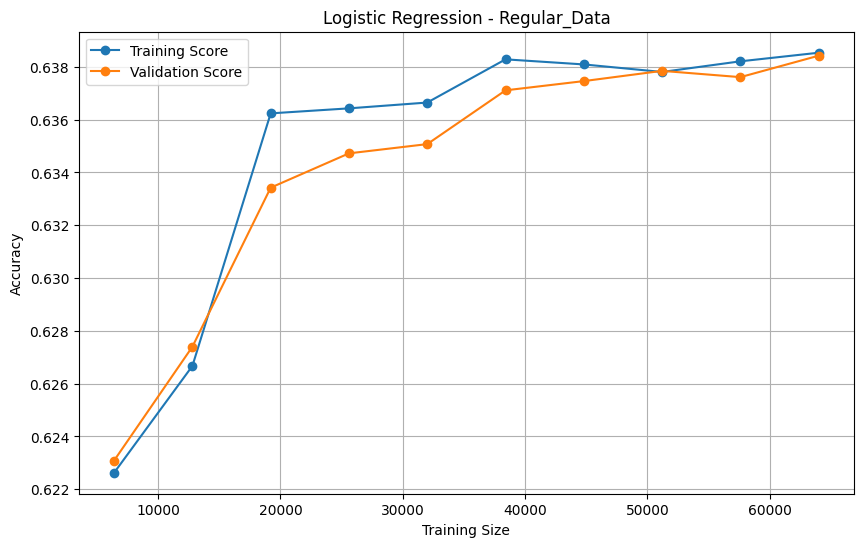

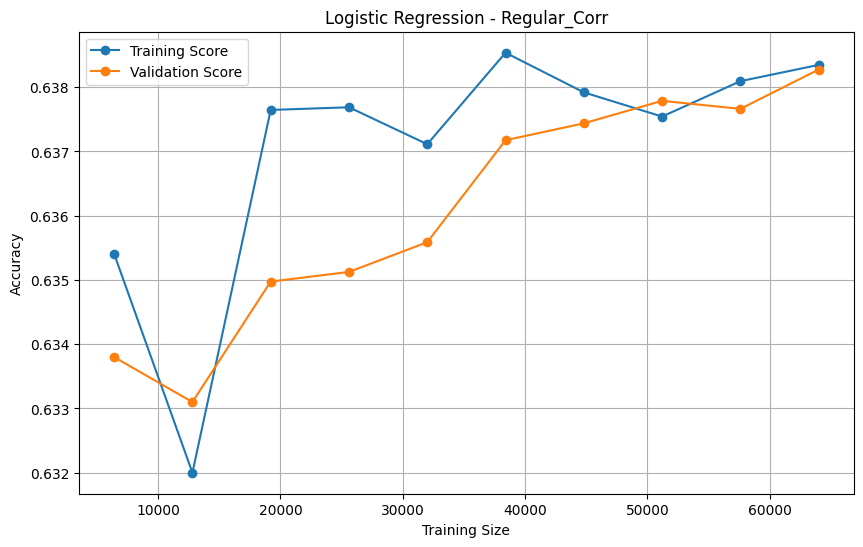

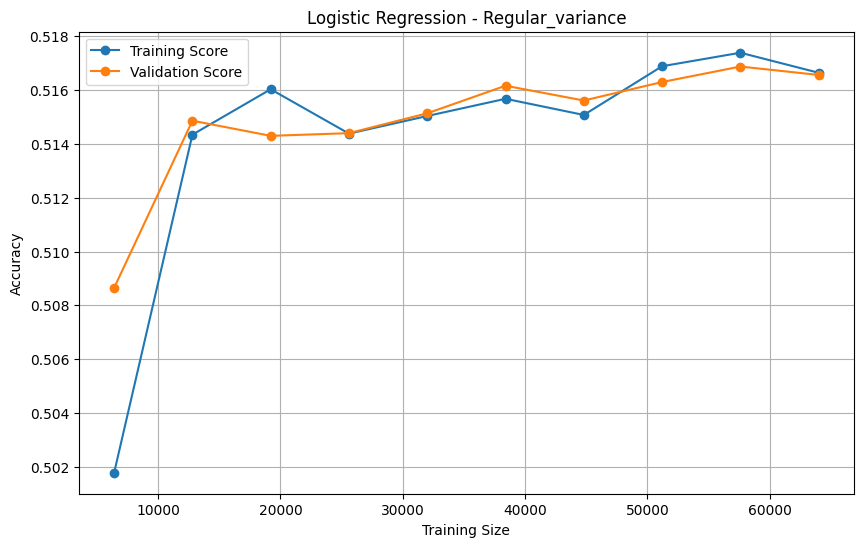

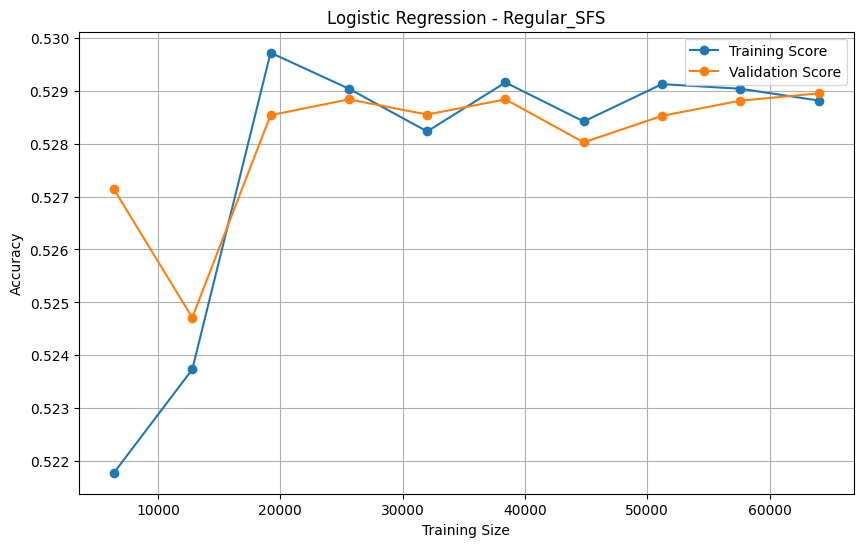

In [88]:
for estimator, X_train, Y_train, name in models_logreg:
    plot_learning_curve(estimator, X_train, Y_train, f"Logistic Regression - {name}")

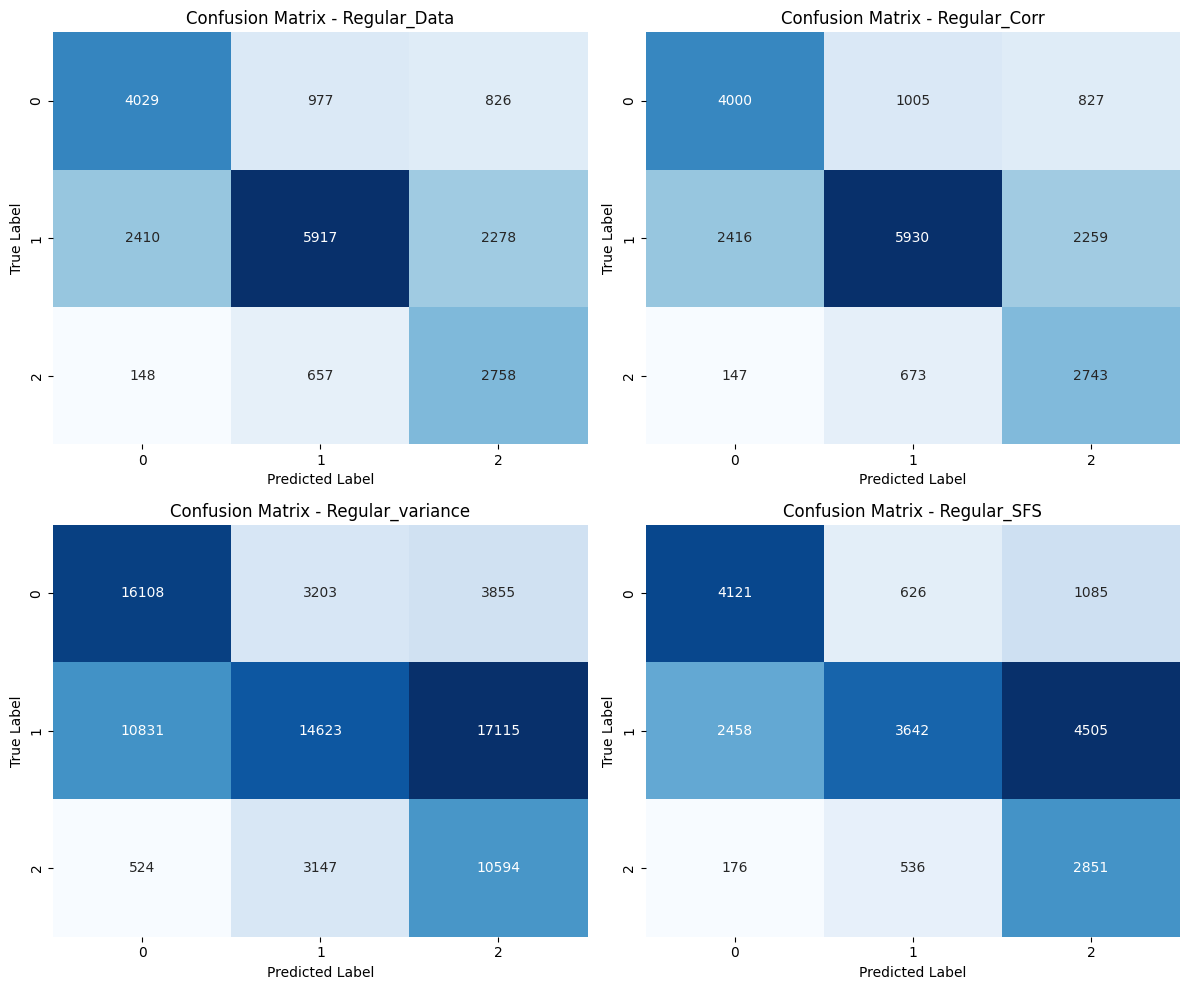

In [100]:
plot_confusion_matrices(confusion_matrices_logreg)

In [ ]:
# Logistic Regression: On each of the following datasets
# 
# Regular_Data: Reached a final accuracy of ~64%
# Regular_Corr_Forest: Reached a final accuracy of ~63%
# Regular_Varriance: Reached a final accuracy of ~51%
# Regular_SFS: Reached a final accuracy of ~53%

# The learning curves shows:
# Underfitting: Only reached an accuracy of 53% - 63%
# No Overfitting: The gap between the training and testing is less than 0.01%

# Overall, this model showed good generalization
# but was unable to learn complex relationships
# it's just too simple

### Training: Decision Tree Classifier

In [91]:
dt_params = {
    'max_depth': [8, 10, 12, 14],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [10, 20, 30],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'ccp_alpha': [0.001, 0.002, 0.003, 0.005] 
}

results_dt = []
models_dt = []
confusion_matrices_dt = []
for X_train, X_test, Y_train, Y_test, name in datasets:
    print(f"\n==================== {name} ====================\n")

    dt = DecisionTreeClassifier(random_state=21)
    grid = GridSearchCV(dt, dt_params, cv=5, n_jobs=-1, verbose=1)
    grid.fit(X_train, Y_train)

    Y_pred = grid.predict(X_test)
    acc = accuracy_score(Y_test, Y_pred)

    print("Best Params:", grid.best_params_)
    print(classification_report(Y_test, Y_pred))
    
    cm = confusion_matrix(Y_test, Y_pred)
    confusion_matrices_dt.append((name, cm))
    results_dt.append([name, acc])
    models_dt.append((grid.best_estimator_, X_train, Y_train, name))

results_dt_df = pd.DataFrame(results_dt, columns=["Dataset", "Accuracy"])
print("\n=========== FINAL ACCURACY SUMMARY ===========\n")
print(results_dt_df.to_string(index=False))


==================== Regular_Data ====================

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Best Params: {'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 30}
              precision    recall  f1-score   support

           0       0.65      0.63      0.64      5832
           1       0.73      0.69      0.71     10605
           2       0.52      0.63      0.57      3563

    accuracy                           0.66     20000
   macro avg       0.63      0.65      0.64     20000
weighted avg       0.67      0.66      0.66     20000


==================== Regular_Corr ====================

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Best Params: {'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 30}
              precision    recall  f1-score   support

           0       0.72   

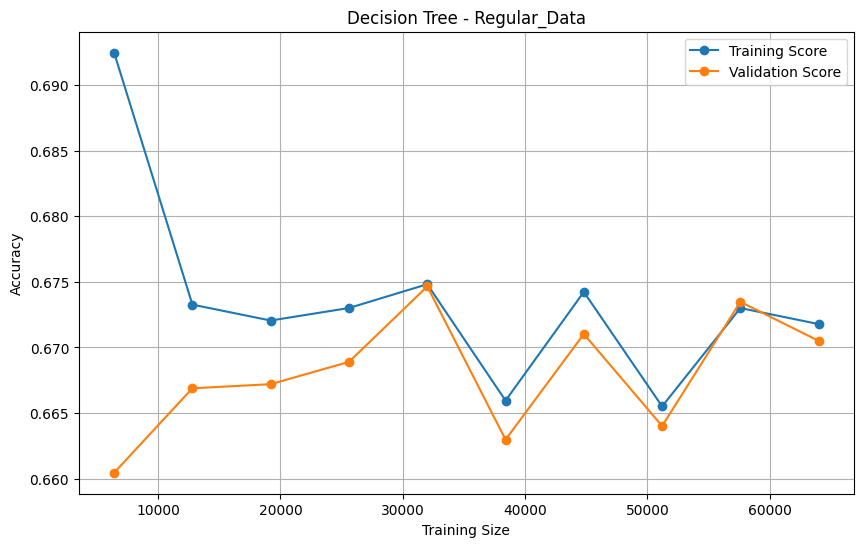

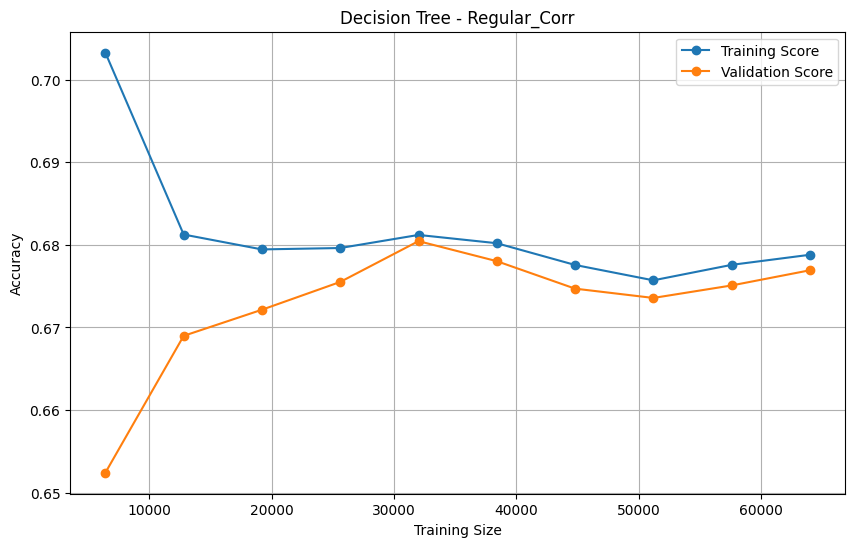

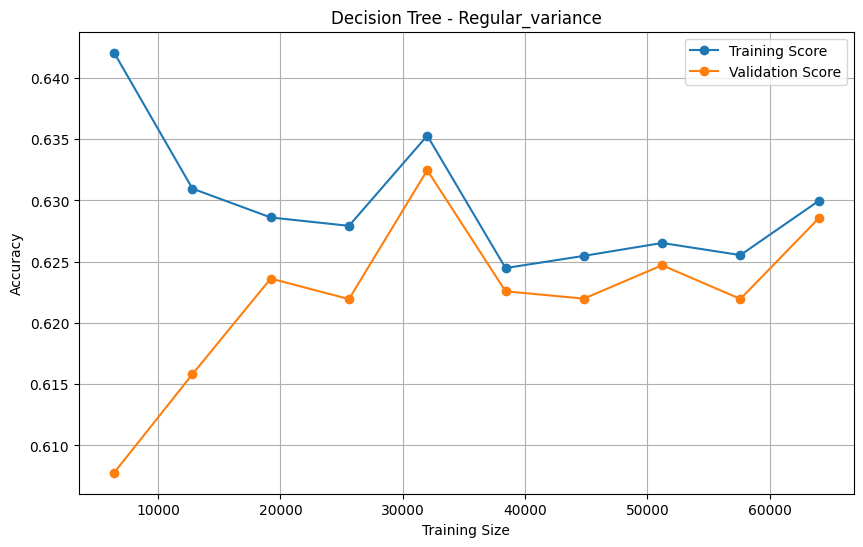

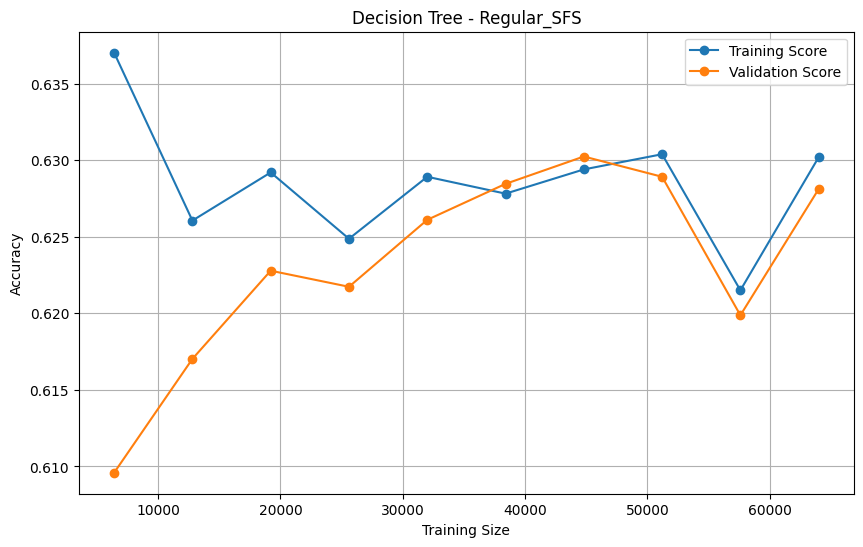

In [92]:
# Plot learning curves for all Decision Tree models
for estimator, X_train, Y_train, name in models_dt:
    plot_learning_curve(estimator, X_train, Y_train, f"Decision Tree - {name}")

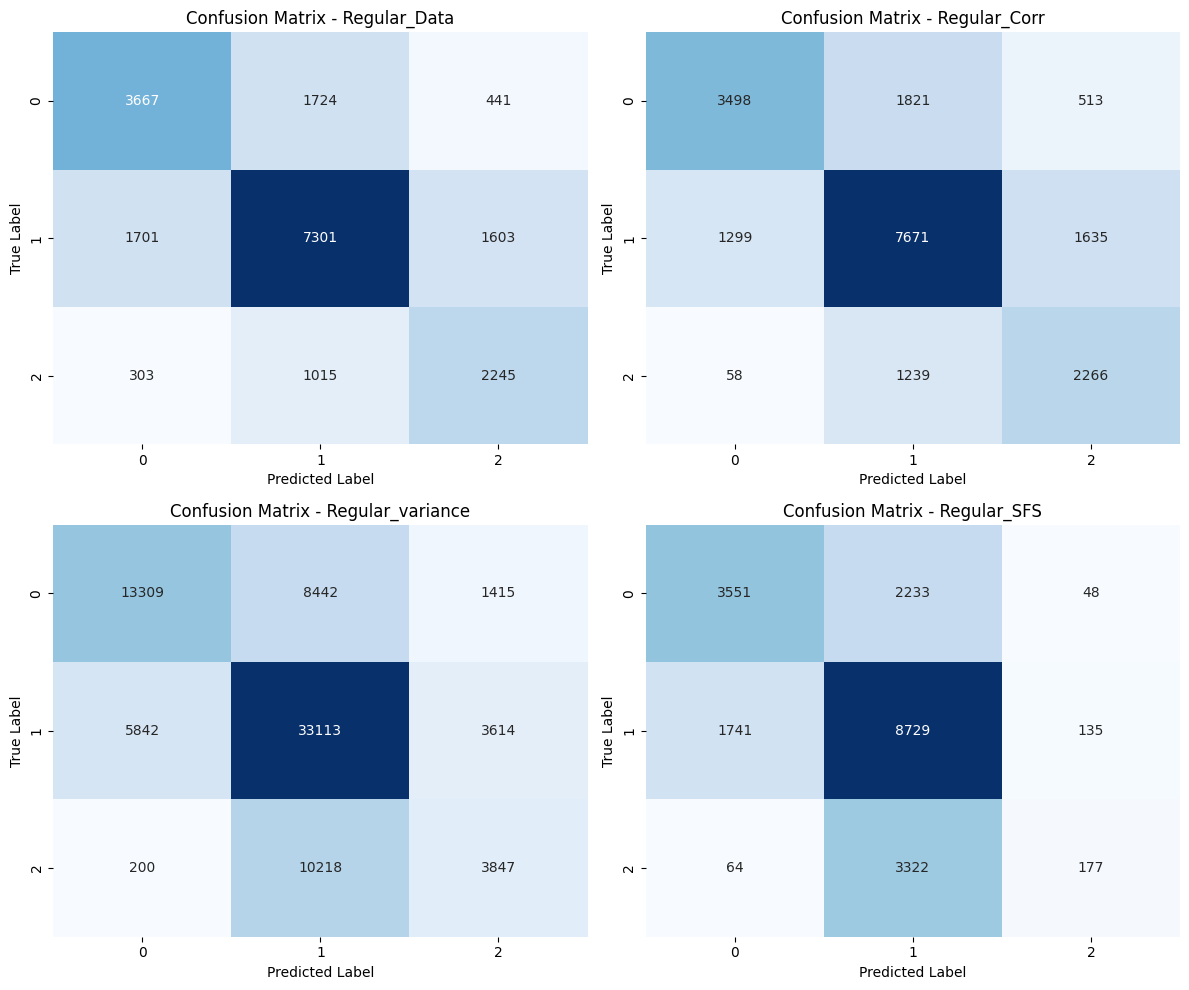

In [101]:
plot_confusion_matrices(confusion_matrices_dt)

In [ ]:
# Decision Tree Classifier: On each of the following datasets

# Regular_Data: Reached a final accuracy of ~66%
# Regular_Corr_Forest: Reached a final accuracy of ~67%
# Regular_Varriance: Reached a final accuracy of ~63%
# Regular_SFS: Reached a final accuracy of ~61%

# Underfitting: only reached an accuracy of 61% - 67%
# No Overfitting: the gap between the training and testing is less than 1%

# Overall, this model showed good generalization
# but was unable to learn complex relationships

### Training: K-Nearest Neighbors (KNN)

In [95]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_params = {
    'knn__n_neighbors': [15, 25, 35, 50, 75, 100, 150, 200],
    'knn__weights': ['uniform'],
    'knn__metric': ['euclidean', 'manhattan']
}

results_knn = []
models_knn = []
confusion_matrices_knn = []

for X_train, X_test, Y_train, Y_test, name in datasets:
    print(f"\n==================== {name} ====================\n")

    grid = GridSearchCV(knn_pipe, knn_params, cv=5, n_jobs=-1, verbose=1)
    grid.fit(X_train, Y_train)

    Y_pred = grid.predict(X_test)
    acc = accuracy_score(Y_test, Y_pred)

    print("Best Params:", grid.best_params_)
    print(classification_report(Y_test, Y_pred))

    cm = confusion_matrix(Y_test, Y_pred)
    confusion_matrices_knn.append((name, cm))
    results_knn.append([name, acc])
    models_knn.append((grid.best_estimator_, X_train, Y_train, name))

results_knn_df = pd.DataFrame(results_knn, columns=["Dataset", "Accuracy"])
print("\n=========== ACCURACY SUMMARY ===========\n")
print(results_knn_df.to_string(index=False))


==================== Regular_Data ====================

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'uniform'}
              precision    recall  f1-score   support

           0       0.74      0.68      0.71      5832
           1       0.72      0.80      0.76     10605
           2       0.66      0.53      0.58      3563

    accuracy                           0.72     20000
   macro avg       0.71      0.67      0.69     20000
weighted avg       0.72      0.72      0.72     20000


==================== Regular_Corr ====================

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'uniform'}
              precision    recall  f1-score   support

           0       0.74      0.69      0.71      5832
           1       0.73      0.79      0.76     10605
           2       0.63      0.54 

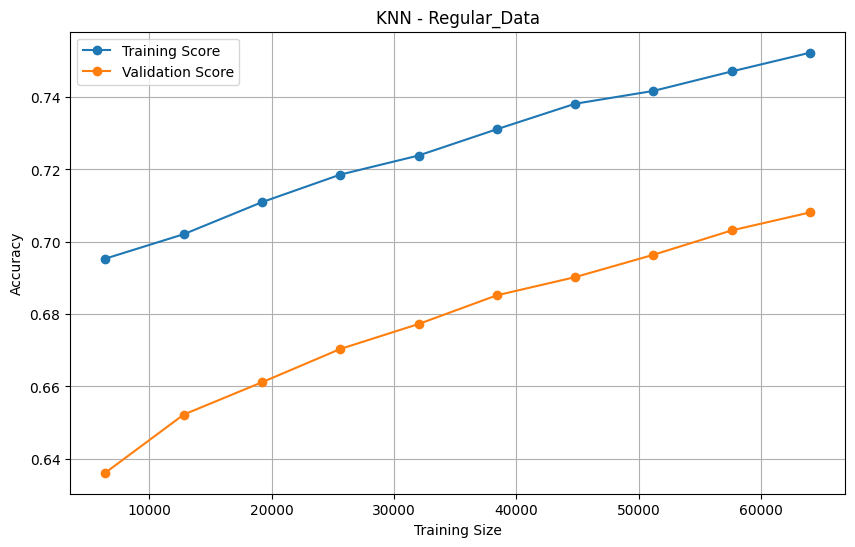

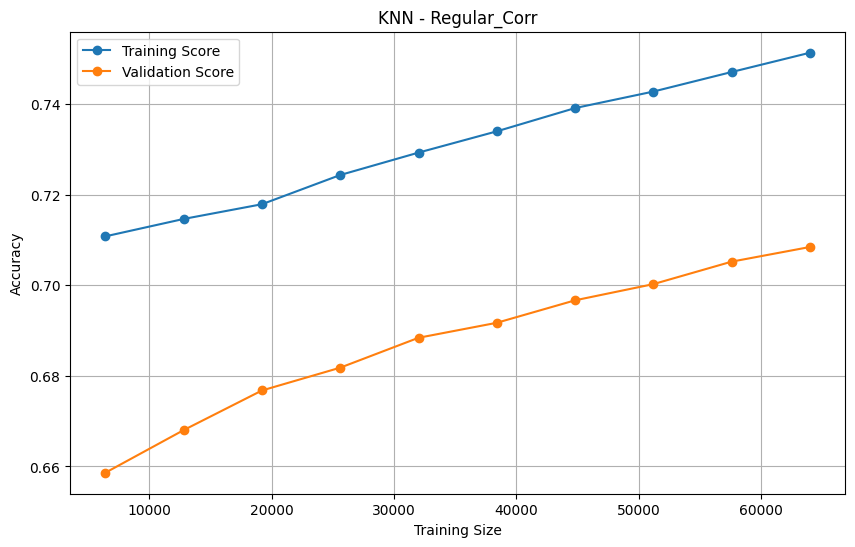

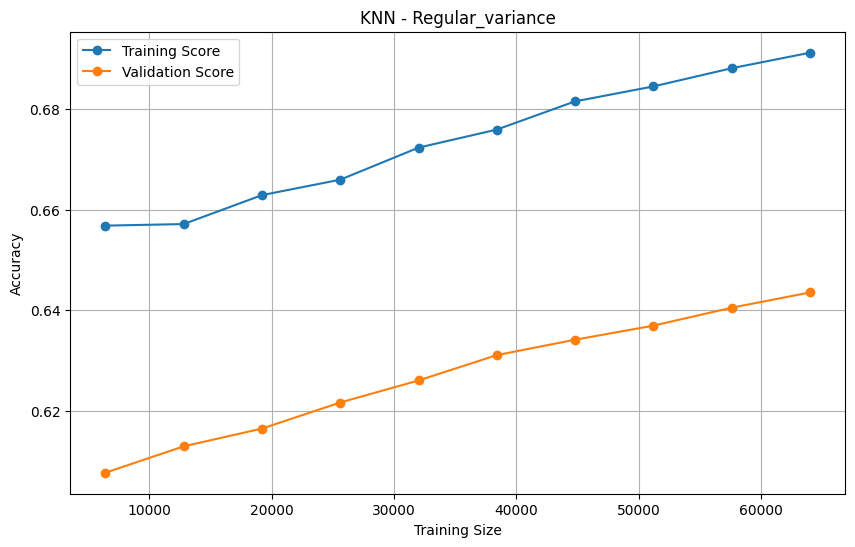

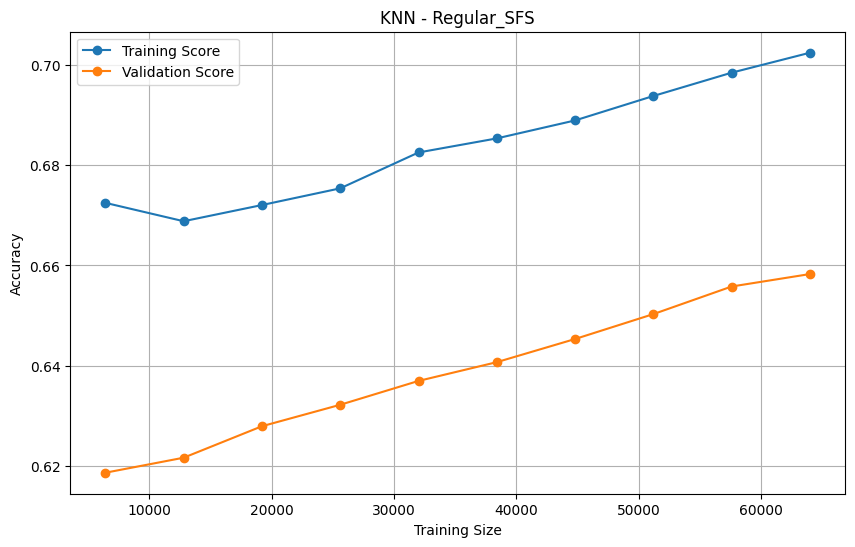

In [96]:
# Plot learning curves for all KNN models
for estimator, X_train, Y_train, name in models_knn:
    plot_learning_curve(estimator, X_train, Y_train, f"KNN - {name}")

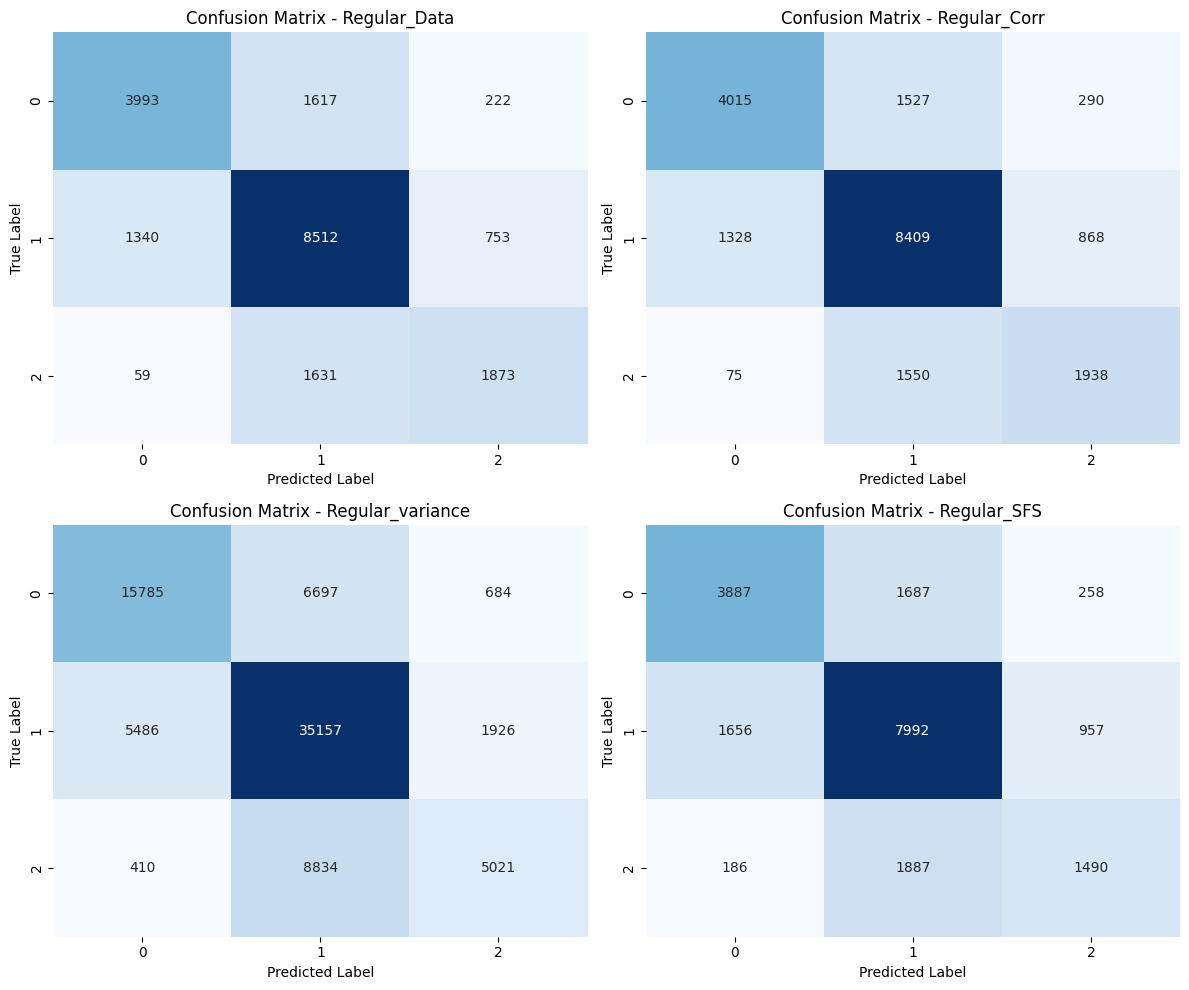

In [102]:
plot_confusion_matrices(confusion_matrices_knn)

In [ ]:
# K-Nearest Neighbors (KNN): On each of the following datasets
# 
# Regular_Data: Reached a final accuracy of ~72%
# Regular_Corr_Forest: Reached a final accuracy of ~72%
# Regular_Varriance: Reached a final accuracy of ~70%
# Regular_SFS: Reached a final accuracy of ~67%

# The learning curves shows:
# Underfitting: only reached an accuracy of 67% - 72%
# No Overfitting: the gap between the training and testing is less than 4%

# Overall, this model showed good generalization, and was able to learn more
# complex non linear relationships, but is difficule to tune to get higher
# accuracy